# H4 分子势能面计算（修复版）

本 notebook 计算 H4 分子在不同键长下的 FCI、HF 和 VMC (FFNN) 能量，绘制势能面曲线。

修复了短键长时 VMC 优化失败的问题。

In [1]:
import numpy as np
import netket as nk
import matplotlib.pyplot as plt
import json
from pyscf import gto, scf, fci
import netket.experimental as nkx
from tqdm import tqdm

bond_distance = np.round(np.linspace(0.4, 2.0, 17), 2)

/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 计算 FCI 和 HF 能量

In [2]:
H4_E_FCI = []
H4_E_HF = []
H4_nuclear_repulsion = []
for bond_length in tqdm(bond_distance):
    geometry = [
        ('H', (0., 0., 0.)),
        ('H', (bond_length, 0., 0.)),
        ('H', (bond_length*2, 0., 0.)),
        ('H', (bond_length*3, 0., 0.)),
    ]

    mol = gto.M(atom=geometry, basis='STO-3G')

    mf = scf.RHF(mol).run(verbose=0)
    E_hf = mf.e_tot
    nuclear_repulsion = mol.energy_nuc()
    H4_nuclear_repulsion.append(nuclear_repulsion)
    
    cisolver = fci.FCI(mf)
    E_fci, fcivec = cisolver.kernel()
    H4_E_FCI.append(E_fci)
    H4_E_HF.append(E_hf)
    
with open('H4_E_FCI_HF.npz', 'wb') as f:
    np.savez(f, E_FCI=H4_E_FCI, E_HF=H4_E_HF, E_nuclear_repulsion=H4_nuclear_repulsion, bond_length=bond_distance)

100%|██████████| 17/17 [00:00<00:00, 25.21it/s]


## 绘制 FCI 和 HF 势能面

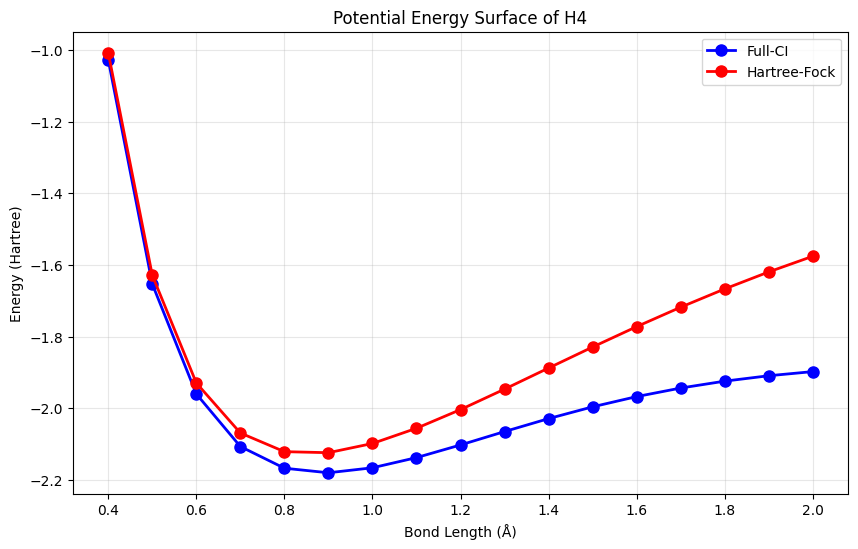

FCI 最小能量: -2.180317 Hartree
HF 最小能量: -2.124260 Hartree
FCI 平衡键长: 0.90 Å
HF 平衡键长: 0.90 Å


In [3]:
with open('H4_E_FCI_HF.npz', 'rb') as f:
    data = np.load(f)
    E_FCI = data['E_FCI']
    E_HF = data['E_HF']
    E_nuclear_repulsion = data['E_nuclear_repulsion']
    bond_length = data['bond_length']

plt.figure(figsize=(10, 6))
plt.plot(bond_length, E_FCI, 'bo-', linewidth=2, markersize=8, label='Full-CI')
plt.plot(bond_length, E_HF, 'ro-', linewidth=2, markersize=8, label='Hartree-Fock')
plt.legend()
plt.xlabel('Bond Length (Å)')
plt.ylabel('Energy (Hartree)')
plt.title('Potential Energy Surface of H4')
plt.grid(True, alpha=0.3)
plt.show()

print(f"FCI 最小能量: {np.min(E_FCI):.6f} Hartree")
print(f"HF 最小能量: {np.min(E_HF):.6f} Hartree")
print(f"FCI 平衡键长: {bond_length[np.argmin(E_FCI)]:.2f} Å")
print(f"HF 平衡键长: {bond_length[np.argmin(E_HF)]:.2f} Å")

## VMC 计算 (FFNN) - 修复版

In [4]:
import itertools
import jax
import jax.numpy as jnp
from flax import nnx

# 排列组合
letters_alpha = [0, 1, 2, 3]
letters_beta = [4, 5, 6, 7]
combinations_alpha = itertools.combinations(letters_alpha, 2)
combinations_beta = itertools.combinations(letters_beta, 2)
clusters = list(combinations_alpha) + list(combinations_beta)

hi = nk.hilbert.SpinOrbitalFermions(
    n_orbitals=4,  # 总空间轨道数
    s = 1/2,
    n_fermions_per_spin=(2, 2)  # 每种自旋的电子数
)
g = nk.graph.Graph(edges=clusters)
sa = nk.sampler.MetropolisFermionHop(
    hi, graph=g, n_chains=16, spin_symmetric=True, sweep_size=64
)

In [5]:
class FFN_Amplitude(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    

class FFN_Phase(nnx.Module):

    def __init__(self, N: int, alpha: int = 1, *, rngs: nnx.Rngs):
        self.alpha = alpha
        self.linear = nnx.Linear(in_features=N, out_features=alpha * N, rngs=rngs)

    def __call__(self, x: jax.Array):
        y = self.linear(x)
        y = nnx.relu(y)
        return jnp.sum(y, axis=-1)
    
class FFN(nnx.Module):
    def __init__(self, N: int, alpha: int, rngs_amplitude: nnx.Rngs, rngs_phase: nnx.Rngs) -> None:
        self.ffn_amplitude = FFN_Amplitude(N=N, alpha=alpha, rngs=rngs_amplitude)
        self.ffn_phase = FFN_Phase(N=N, alpha=alpha, rngs=rngs_phase)
        
    def __call__(self, x: jax.Array):
        y = self.ffn_amplitude(x) + 1j*self.ffn_phase(x)
        return y

In [6]:
ffnn_energy = []
failed_bond_lengths = []

for i, bond_length in enumerate(tqdm(bond_distance)):
    print(f'当前 bond_length: {bond_length:.2f}')
    
    geometry = [
        ('H', (0., 0., 0.)),
        ('H', (bond_length, 0., 0.)),
        ('H', (bond_length*2, 0., 0.)),
        ('H', (bond_length*3, 0., 0.)),
    ]
    
    mol = gto.M(atom=geometry, basis='STO-3G')
    ha = nkx.operator.from_pyscf_molecule(mol)
    
    # 使用不同的随机种子，避免每次循环使用相同的初始化
    ffnn_model = FFN(N=8, alpha=1, rngs_amplitude=nnx.Rngs(i*2), rngs_phase=nnx.Rngs(i*2+1))
    vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)
    
    # 对于短键长使用更小的学习率
    if bond_length < 0.8:
        lr = 0.01
        n_iter = 300
    else:
        lr = 0.05
        n_iter = 200
    
    opt = nk.optimizer.Sgd(learning_rate=lr)
    sr = nk.optimizer.SR(diag_shift=0.01)
    
    gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)
    
    exp_name = f"h4_bond_{bond_length:.2f}"
    
    try:
        gs.run(n_iter, out=exp_name)
        energy = gs.energy.mean
        
        # 检查能量是否为 NaN
        if np.isnan(energy.real) or np.isnan(energy.imag):
            print(f"  警告: bond_length={bond_length:.2f} 的能量为 NaN")
            failed_bond_lengths.append(bond_length)
            ffnn_energy.append(np.nan)
        else:
            ffnn_energy.append(energy)
            print(f"  能量: {energy.real:.6f} Ha")
    except Exception as e:
        print(f"  错误: bond_length={bond_length:.2f} 优化失败: {e}")
        failed_bond_lengths.append(bond_length)
        ffnn_energy.append(np.nan)

with open('H4_FFNN_alpha_1.npz', 'wb') as f:
    np.savez(f, E_FFNN=ffnn_energy, bond_length=bond_distance)

print(f"\n失败的键长: {failed_bond_lengths}")

  0%|          | 0/17 [00:00<?, ?it/s]

当前 bond_length: 0.40


  6%|▌         | 1/17 [00:38<10:17, 38.61s/it]

  能量: -1.007369 Ha
当前 bond_length: 0.50


 12%|█▏        | 2/17 [00:58<06:53, 27.59s/it]

...

  能量: -1.839020 Ha
当前 bond_length: 1.90


 94%|█████████▍| 16/17 [06:04<00:18, 18.83s/it]

  能量: -1.854495 Ha
当前 bond_length: 2.00


100%|██████████| 17/17 [06:20<00:00, 22.40s/it]

  能量: -1.868673 Ha

失败的键长: [0.6]


In [ ]:
ffnn_energy_alpha2 = []
failed_bond_lengths = []

for i, bond_length in enumerate(tqdm(bond_distance)):
    print(f'当前 bond_length: {bond_length:.2f}')
    
    geometry = [
        ('H', (0., 0., 0.)),
        ('H', (bond_length, 0., 0.)),
        ('H', (bond_length*2, 0., 0.)),
        ('H', (bond_length*3, 0., 0.)),
    ]
    
    mol = gto.M(atom=geometry, basis='STO-3G')
    ha = nkx.operator.from_pyscf_molecule(mol)
    
    # 使用不同的随机种子，避免每次循环使用相同的初始化
    ffnn_model = FFN(N=8, alpha=2, rngs_amplitude=nnx.Rngs(i*2), rngs_phase=nnx.Rngs(i*2+1))
    vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)
    
    # 对于短键长使用更小的学习率
    if bond_length < 0.8:
        lr = 0.01
        n_iter = 300
    else:
        lr = 0.05
        n_iter = 200
    
    opt = nk.optimizer.Sgd(learning_rate=lr)
    sr = nk.optimizer.SR(diag_shift=0.01)
    
    gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)
    
    exp_name = f"h4_bond_{bond_length:.2f}"
    
    try:
        gs.run(n_iter, out=exp_name)
        energy = gs.energy.mean
        
        # 检查能量是否为 NaN
        if np.isnan(energy.real) or np.isnan(energy.imag):
            print(f"  警告: bond_length={bond_length:.2f} 的能量为 NaN")
            failed_bond_lengths.append(bond_length)
            ffnn_energy.append(np.nan)
        else:
            ffnn_energy.append(energy)
            print(f"  能量: {energy.real:.6f} Ha")
    except Exception as e:
        print(f"  错误: bond_length={bond_length:.2f} 优化失败: {e}")
        failed_bond_lengths.append(bond_length)
        ffnn_energy_alpha2.append(np.nan)

with open('H4_FFNN_alpha_2.npz', 'wb') as f:
    np.savez(f, E_FFNN=ffnn_energy_alpha2, bond_length=bond_distance)

print(f"\n失败的键长: {failed_bond_lengths}")

  0%|          | 0/17 [00:00<?, ?it/s]

当前 bond_length: 0.40


  6%|▌         | 1/17 [00:14<03:57, 14.84s/it]

  能量: -1.007375 Ha
当前 bond_length: 0.50


 12%|█▏        | 2/17 [00:29<03:37, 14.51s/it]

...

  能量: -1.907938 Ha
当前 bond_length: 1.90


 94%|█████████▍| 16/17 [03:43<00:14, 14.56s/it]

  能量: -1.854716 Ha
当前 bond_length: 2.00


100%|██████████| 17/17 [04:07<00:00, 14.58s/it]

  能量: -1.868761 Ha

失败的键长: []


In [25]:
ffnn_energy_alpha3 = []
failed_bond_lengths = []

for i, bond_length in enumerate(tqdm(bond_distance)):
    print(f'当前 bond_length: {bond_length:.2f}')
    
    geometry = [
        ('H', (0., 0., 0.)),
        ('H', (bond_length, 0., 0.)),
        ('H', (bond_length*2, 0., 0.)),
        ('H', (bond_length*3, 0., 0.)),
    ]
    
    mol = gto.M(atom=geometry, basis='STO-3G')
    ha = nkx.operator.from_pyscf_molecule(mol)
    
    # 使用不同的随机种子，避免每次循环使用相同的初始化
    ffnn_model = FFN(N=8, alpha=3, rngs_amplitude=nnx.Rngs(i*2), rngs_phase=nnx.Rngs(i*2+1))
    vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)
    
    # 对于短键长使用更小的学习率
    if bond_length < 0.8:
        lr = 0.01
        n_iter = 300
    else:
        lr = 0.05
        n_iter = 200
    
    opt = nk.optimizer.Sgd(learning_rate=lr)
    sr = nk.optimizer.SR(diag_shift=0.01)
    
    gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)
    
    exp_name = f"h4_bond_{bond_length:.2f}"
    
    try:
        gs.run(n_iter, out=exp_name)
        energy = gs.energy.mean
        
        # 检查能量是否为 NaN
        if np.isnan(energy.real) or np.isnan(energy.imag):
            print(f"  警告: bond_length={bond_length:.2f} 的能量为 NaN")
            failed_bond_lengths.append(bond_length)
            ffnn_energy_alpha3.append(np.nan)
        else:
            ffnn_energy_alpha3.append(energy)
            print(f"  能量: {energy.real:.6f} Ha")
    except Exception as e:
        print(f"  错误: bond_length={bond_length:.2f} 优化失败: {e}")
        failed_bond_lengths.append(bond_length)
        ffnn_energy_alpha3.append(np.nan)

with open('H4_FFNN_alpha_3.npz', 'wb') as f:
    np.savez(f, E_FFNN=ffnn_energy_alpha3, bond_length=bond_distance)

print(f"\n失败的键长: {failed_bond_lengths}")

  0%|          | 0/17 [00:00<?, ?it/s]

当前 bond_length: 0.40


  6%|▌         | 1/17 [00:12<03:27, 12.96s/it]

  警告: bond_length=0.40 的能量为 NaN
当前 bond_length: 0.50


 12%|█▏        | 2/17 [00:21<02:38, 10.54s/it]

...

  能量: -1.889253 Ha
当前 bond_length: 1.90


 94%|█████████▍| 16/17 [02:08<00:07,  7.36s/it]

  能量: -1.758445 Ha
当前 bond_length: 2.00


100%|██████████| 17/17 [02:15<00:00,  7.96s/it]

  能量: -1.788528 Ha

失败的键长: [0.4, 0.8]


In [33]:
RBM_energy = []
failed_bond_lengths = []

for i, bond_length in enumerate(tqdm(bond_distance)):
    print(f'当前 bond_length: {bond_length:.2f}')
    
    geometry = [
        ('H', (0., 0., 0.)),
        ('H', (bond_length, 0., 0.)),
        ('H', (bond_length*2, 0., 0.)),
        ('H', (bond_length*3, 0., 0.)),
    ]
    
    mol = gto.M(atom=geometry, basis='STO-3G')
    ha = nkx.operator.from_pyscf_molecule(mol)
    
    # 使用不同的随机种子，避免每次循环使用相同的初始化
    ffnn_model = nk.models.RBMModPhase(alpha=2, param_dtype=complex)
    vs = nk.vqs.MCState(sa, ffnn_model, n_discard_per_chain=10, n_samples=512)
    
    # 对于短键长使用更小的学习率
    if bond_length < 0.8:
        lr = 0.01
        n_iter = 300
    else:
        lr = 0.05
        n_iter = 200
    
    opt = nk.optimizer.Sgd(learning_rate=lr)
    sr = nk.optimizer.SR(diag_shift=0.01)
    
    gs = nk.driver.VMC(ha, opt, variational_state=vs, preconditioner=sr)
    
    exp_name = f"h4_bond_{bond_length:.2f}"
    
    try:
        gs.run(n_iter, out=exp_name)
        energy = gs.energy.mean
        
        # 检查能量是否为 NaN
        if np.isnan(energy.real) or np.isnan(energy.imag):
            print(f"  警告: bond_length={bond_length:.2f} 的能量为 NaN")
            failed_bond_lengths.append(bond_length)
            RBM_energy.append(np.nan)
        else:
            RBM_energy.append(energy)
            print(f"  能量: {energy.real:.6f} Ha")
    except Exception as e:
        print(f"  错误: bond_length={bond_length:.2f} 优化失败: {e}")
        failed_bond_lengths.append(bond_length)
        RBM_energy.append(np.nan)

with open('H4_RBM_alpha2.npz', 'wb') as f:
    np.savez(f, E_FFNN=RBM_energy, bond_length=bond_distance)

print(f"\n失败的键长: {failed_bond_lengths}")

  0%|          | 0/17 [00:00<?, ?it/s]

当前 bond_length: 0.40


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generate

  能量: -1.007365 Ha
当前 bond_length: 0.50


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generate

...

  能量: -1.686299 Ha
当前 bond_length: 1.90


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generate

  能量: -1.837634 Ha
当前 bond_length: 2.00


/opt/miniconda3/envs/Neural/lib/python3.11/site-packages/netket/optimizer/qgt/qgt_onthefly.py:139: HolomorphicUndeclaredWarning: 
Defaulting to `holomorphic=False`, but this might lead to increased
computational cost or disabled features. Check if your variational
function is holomorphic, and if so specify `holomorphic=True`as an extra
keyword argument.

To silence this warning, specify the `holomorphic=False/True` keyword
argument.

To numerically check whether your variational function is or not holomorphic
you can use the following snippet:

```python
   vs = nk.vqs.MCState(...)

   nk.utils.is_probably_holomorphic(vs._apply_fun, vs.parameters, vs.samples, vs.model_state)
```

if `nk.utils.is_probably_holomorphic` returns False, then your function is not holomorphic.
If it returns True, it is probably holomorphic.


-------------------------------------------------------
For more detailed informations, visit the following link:
	 https://netket.readthedocs.io/en/latest/api/_generate

  能量: -1.703348 Ha

失败的键长: []


## 绘制完整的势能面 (FCI, HF, VMC)

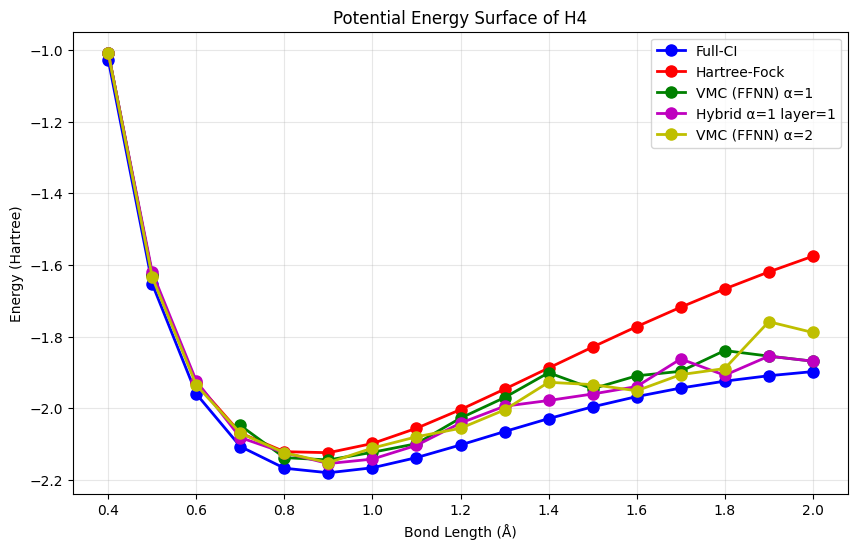

FCI 最小能量: -2.180317 Hartree
HF 最小能量: -2.124260 Hartree
VMC 最小能量: -2.144541 Hartree
FCI 平衡键长: 0.90 Å
HF 平衡键长: 0.90 Å
VMC 平衡键长: 0.90 Å


In [39]:
with open('H4_FFNN_alpha_1.npz', 'rb') as f:
    data = np.load(f)
    E_FFNN = data['E_FFNN']
    bond_length_ffnn = data['bond_length']
    
with open('H4_FFNN_alpha_2.npz', 'rb') as f:
    data = np.load(f)
    E_FFNN_2 = data['E_FFNN']
    bond_length_ffnn = data['bond_length']

# with open('H4_FFNN_alpha_3.npz', 'rb') as f:
#     data = np.load(f)
#     E_FFNN_3 = data['E_FFNN']
#     bond_length_ffnn = data['bond_length']
with open('H4_RBM_alpha2.npz', 'rb') as f:
    data = np.load(f)
    E_FFNN_4 = data['E_FFNN']
    bond_length_ffnn = data['bond_length']
    
with open('H4_E_FCI_HF.npz', 'rb') as f:
    data = np.load(f)
    E_FCI = data['E_FCI']
    E_HF = data['E_HF']
    bond_length = data['bond_length']

# 提取 VMC 能量的实部
E_FFNN_real = np.array([e.real if not np.isnan(e) else np.nan for e in E_FFNN])
E_FFNN_real_2 = np.array([e.real if not np.isnan(e) else np.nan for e in E_FFNN_2])
E_FFNN_real_3 = np.array([e.real if not np.isnan(e) else np.nan for e in E_FFNN_3])
#E_FFNN_real_4 = np.array([e.real if not np.isnan(e) else np.nan for e in E_FFNN_4])



plt.figure(figsize=(10, 6))
plt.plot(bond_length, E_FCI, 'bo-', linewidth=2, markersize=8, label='Full-CI')
plt.plot(bond_length, E_HF, 'ro-', linewidth=2, markersize=8, label='Hartree-Fock')
plt.plot(bond_length, E_FFNN_real, 'go-', linewidth=2, markersize=8, label='VMC (FFNN) α=1')
plt.plot(bond_length, E_FFNN_real_2, 'mo-', linewidth=2, markersize=8, label='Hybrid α=1 layer=1')
plt.plot(bond_length, E_FFNN_real_3, 'yo-', linewidth=2, markersize=8, label='VMC (FFNN) α=2')
#plt.plot(bond_length, E_FFNN_real_4, 'co-', linewidth=2, markersize=8, label='VMC (RBM) α=2')

plt.legend()
plt.xlabel('Bond Length (Å)')
plt.ylabel('Energy (Hartree)')
plt.title('Potential Energy Surface of H4')
plt.grid(True, alpha=0.3)
plt.show()

# 只统计有效的 VMC 能量
valid_ffnn = [e for e in E_FFNN_real if not np.isnan(e)]
if valid_ffnn:
    print(f"FCI 最小能量: {np.min(E_FCI):.6f} Hartree")
    print(f"HF 最小能量: {np.min(E_HF):.6f} Hartree")
    print(f"VMC 最小能量: {np.min(valid_ffnn):.6f} Hartree")
    print(f"FCI 平衡键长: {bond_length[np.argmin(E_FCI)]:.2f} Å")
    print(f"HF 平衡键长: {bond_length[np.argmin(E_HF)]:.2f} Å")
    valid_indices = [i for i, e in enumerate(E_FFNN_real) if not np.isnan(e)]
    if valid_indices:
        vmc_min_idx = valid_indices[np.argmin([E_FFNN_real[i] for i in valid_indices])]
        print(f"VMC 平衡键长: {bond_length[vmc_min_idx]:.2f} Å")

In [18]:
E_FFNN_real_2

array([-1.00737469, -1.62092814, -1.92428944, -2.08209595, -2.12439682,
       -2.15460537, -2.14213647, -2.10371535, -2.04147926, -1.99449002,
       -1.97848683, -1.96030242, -1.93946969, -1.86243784, -1.9079376 ,
       -1.85471595, -1.86876088])

## 绘制相对于最小能量的势能面

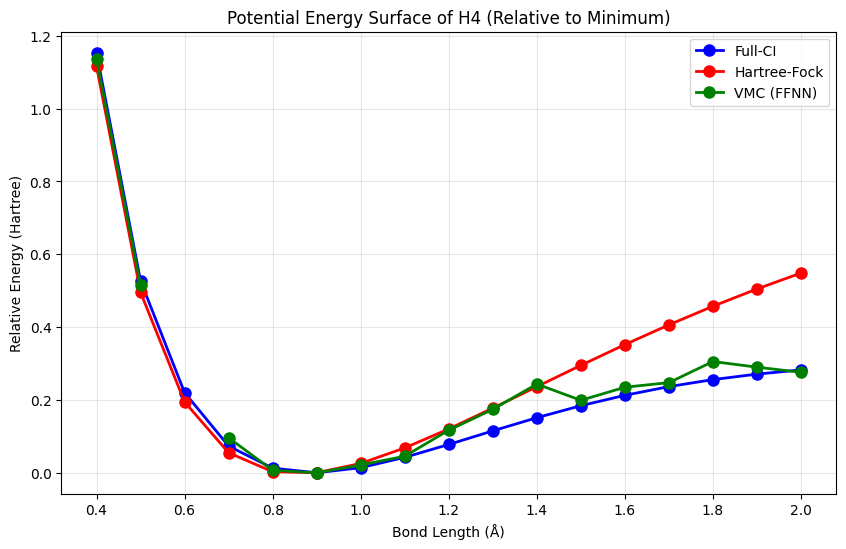

In [8]:
E_FCI_relative = E_FCI - np.min(E_FCI)
E_HF_relative = E_HF - np.min(E_HF)

# 对于 VMC，只使用有效的数据点
valid_mask = ~np.isnan(E_FFNN_real)
E_FFNN_relative = np.full_like(E_FFNN_real, np.nan)
E_FFNN_relative[valid_mask] = E_FFNN_real[valid_mask] - np.nanmin(E_FFNN_real)

plt.figure(figsize=(10, 6))
plt.plot(bond_length, E_FCI_relative, 'bo-', linewidth=2, markersize=8, label='Full-CI')
plt.plot(bond_length, E_HF_relative, 'ro-', linewidth=2, markersize=8, label='Hartree-Fock')
plt.plot(bond_length, E_FFNN_relative, 'go-', linewidth=2, markersize=8, label='VMC (FFNN)')
plt.legend()
plt.xlabel('Bond Length (Å)')
plt.ylabel('Relative Energy (Hartree)')
plt.title('Potential Energy Surface of H4 (Relative to Minimum)')
plt.grid(True, alpha=0.3)
plt.show()